In [337]:
import numpy as np
import pandas as pd

class LUCParcel():
    def __init__(self, t, At, Ct, Cmax, T50):
        self.Cmax = Cmax
        self.T50 = T50

        # Set initial time, area and carbon stock
        self.t = t
        self.At = At
        self.Ct = Ct

        # Create lists for time, area and carbon stock time series
        self.T = [t]
        self.A = [At]
        self.C = [Ct]

    def time_step(self):
        self.t += 1
        alpha = 1 - np.exp(-np.log(2)/self.T50)
        self.Ct = self.Ct + alpha * (self.Cmax - self.Ct)

        self.C += [self.Ct]
        self.A += [self.At]
        self.T += [self.t]

    def stock_time_series(self):
        return pd.Series(
            np.array(self.C) * np.array(self.A),
            index = self.T
        )

    def CO2_emissions(self):
        stock = self.stock_time_series()
        return -stock.diff().fillna(0) * 3.67

class LUCTimeSeries():
    def __init__(
        self,
        A : pd.Series,
        Cmax : tuple[float, float],
        T50 : tuple[float, float],
        extend : int = 0
    ):
        
        if extend > 0:
            A = A.reindex(
                pd.Index(
                    list(range(A.index[0],A.index[-1]+extend+1)),
                    name = A.index.name
                ),
                fill_value = A.iloc[-1]
            )
            
        self.A = A
        self.Cmax = Cmax
        self.T50 = T50

    def calculate_parcels(self):

        Ach = self.A.diff().fillna(0)
        
        init_target_parcel = LUCParcel(self.A.index[0], self.A.diff().where(self.A.diff()>0).sum()*10, self.Cmax[0], self.Cmax[0], self.T50[0])
        init_alt_parcel = LUCParcel(self.A.index[0], -self.A.diff().where(self.A.diff()<0).sum()*10, self.Cmax[1], self.Cmax[1], self.T50[1])
        
        target_LU_parcels = [init_target_parcel]
        alt_LU_parcels = [init_alt_parcel]
        inactive_LU_parcels = []

        for t, Ach in zip(Ach.index, Ach):
            
            if Ach < 0:
                from_parcels = target_LU_parcels
                to_parcels = alt_LU_parcels
                Cmax = self.Cmax[1]
                T50 = self.T50[1]
            elif Ach > 0:
                from_parcels = alt_LU_parcels
                to_parcels = target_LU_parcels
                Cmax = self.Cmax[0]
                T50 = self.T50[0]
            else:
                from_parcels = None
                to_parcels = None
                Cmax = None
                T50 = None

            Ach_abs = abs(Ach)

            if from_parcels is not None:
                while True:
                    last_from_parcel = from_parcels.pop()
                    if last_from_parcel.At > Ach_abs:
                        last_from_parcel.At -= Ach_abs
                        from_parcels.append(last_from_parcel)
                        to_parcels.append(
                            LUCParcel(t, Ach_abs, last_from_parcel.Ct, Cmax, T50)
                        )
                        break
                    else:
                        to_parcels.append(
                            LUCParcel(t, last_from_parcel.At, last_from_parcel.Ct, Cmax, T50)
                        )
                        Ach_abs -= last_from_parcel.At
                        last_from_parcel.At = 0
                        inactive_LU_parcels.append(last_from_parcel)                      
                
            for p in target_LU_parcels + alt_LU_parcels:
                p.time_step()

        self.target_LU_parcels = target_LU_parcels
        self.alt_LU_parcels = alt_LU_parcels
        self.inactive_LU_parcels = inactive_LU_parcels

    def get_stocks(self):
        stocks = []
        for p in self.target_LU_parcels + self.alt_LU_parcels + self.inactive_LU_parcels:
            stocks += [p.stock_time_series()]
        df = pd.concat(stocks,axis=1).reindex(self.A.index).fillna(0).sum(axis=1)
        return df
    
    def get_CO2(self):
        return -self.get_stocks().diff().fillna(0) * 3.67

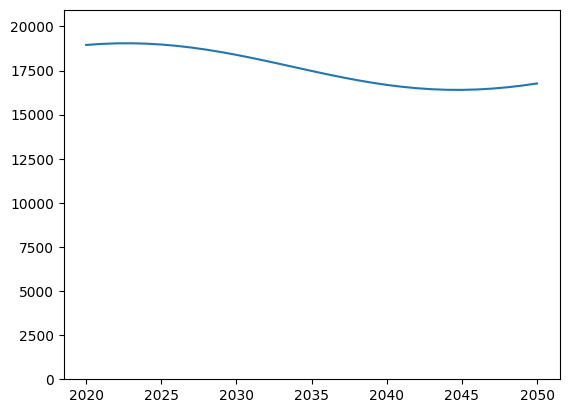

In [362]:
import matplotlib.pyplot as plt

Ct = 0 # kg C/ha, initial forest carbon stock
At = 0 # ha, Area where forest is regenerating
Cin = 2 # kg C/ha, carbon stock in land converted to forest
Cmax = 20 # kg C/ha, maximum carbon stock of forest
T50 = 20 # years, time to reach half Cmax

# Generate land use time series
A = {}
A0 = 2_000_000 / 106
At = A0
for t in range(2020,2050+1):
    Ach = -np.sin(t/7)*(A0/100)# + np.random.randn()*(A0/100/2)
    At += Ach
    A.update({t:At})
A = pd.Series(A)
ax = A.plot()
ax.set_ylim(0,A.max()*1.1)
plt.show()

In [348]:
A.loc[:] = A.iloc[0]

In [363]:
LUCts = LUCTimeSeries(
    A = A,
    Cmax = (5,50),
    T50 = (0.5,20),
    extend = 100
)
LUCts.calculate_parcels()

In [375]:
LUCts.target_LU_parcels[0].A

[4575.0929702279245,
 4575.0929702279245,
 4575.0929702279245,
 4575.0929702279245,
 4575.0929702279245,
 4575.0929702279245,
 4575.0929702279245,
 4525.774342110213,
 4427.975026417345,
 4308.199701968901,
 4168.888608835041,
 4012.8799986610647,
 3843.3523096068275,
 3663.7594105032986,
 3477.7602335280862,
 3289.1442290271734,
 3101.754161227458,
 2919.407817760075,
 2745.8202280438563,
 2584.52797521108,
 2438.8171436049124,
 2311.6563698087193,
 2205.636361190627,
 2122.9171141811275,
 2065.183907630886,
 2033.612967817331,
 2028.847504623136,
 2028.847504623136,
 2028.847504623136,
 2028.847504623136,
 2028.847504623136,
 2028.847504623136,
 2028.847504623136,
 2028.847504623136,
 2028.847504623136,
 2028.847504623136,
 2028.847504623136,
 2028.847504623136,
 2028.847504623136,
 2028.847504623136,
 2028.847504623136,
 2028.847504623136,
 2028.847504623136,
 2028.847504623136,
 2028.847504623136,
 2028.847504623136,
 2028.847504623136,
 2028.847504623136,
 2028.847504623136,
 2028

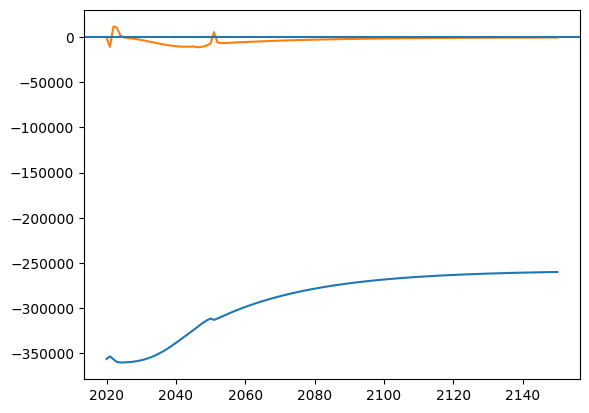

In [364]:
# ax = LUCts.A.plot()
ax = LUCts.get_stocks().sub(1.7e6).plot()
ax = LUCts.get_CO2().plot()
ax.axhline(0)


In [88]:
A0/1_000

2000.0

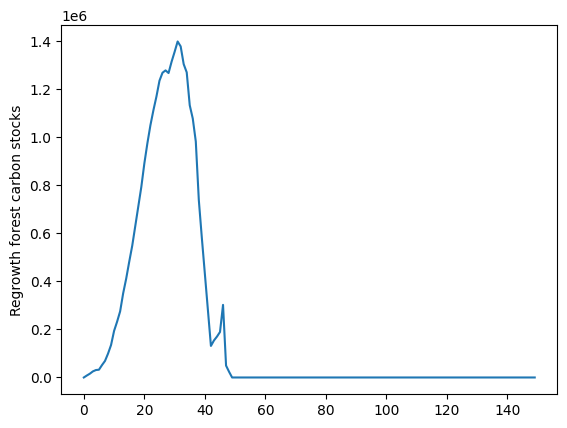

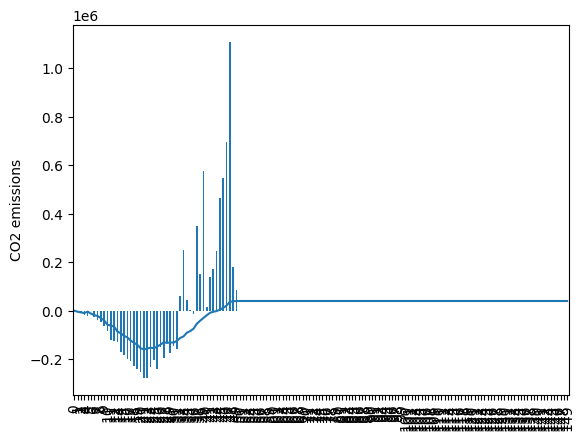

769563.0284168102

In [39]:
forest_parcels = []
inactive_parcels = []
old_forest_parcels = []

for t in range(len(A)):
    if A[t] is A[0]:
        Ach = 0
    else:
        Ach = A[t] - A[t-1]
    
    if Ach < 0:
        forest_parcels.append(ForestParcel(t, -Ach, Cin, Cmax, T50))
    elif Ach > 0:
        while True:
            try:
                last_parcel = forest_parcels.pop()
            except IndexError:
                old_forest_parcel = ForestParcel(t-1, Ach, Cmax, Cmax, T50)
                old_forest_parcel.At += -Ach
                old_forest_parcel.time_step()
                old_forest_parcels.append(old_forest_parcel)
                break
            if last_parcel.At > Ach:
                last_parcel.At += -Ach
                forest_parcels.append(last_parcel)
                break
            else:
                Ach += -last_parcel.At
                last_parcel.At = 0
                inactive_parcels.append(last_parcel)
                
        
    for p in forest_parcels:
        p.time_step()

stocks = []
CO2 = []
for p in forest_parcels + inactive_parcels + old_forest_parcels:
    stocks += [p.stock_time_series()]
    CO2 += [p.CO2_emissions()]

d1 = pd.concat(stocks,axis=1).reindex(range(len(A))).fillna(0).sum(axis=1)
d1.plot(ylabel='Regrowth forest carbon stocks')
plt.show()

d2 = pd.concat(CO2,axis=1).reindex(range(len(A))).fillna(0).sum(axis=1)
ax = d2.plot.bar(ylabel='CO2 emissions')
ax.plot(pd.Series(A)-2_000_000)
plt.show()
d2.sum()

In [27]:
d1.index

Index([ 3,  4, 26, 27, 25, 24, 23, 28, 30, 31, 22, 29, 20, 21, 19, 18, 32, 33,
       17, 16, 34, 15, 14, 13, 35, 12, 11, 36, 37, 10, 38, 39, 40,  9, 41,  8,
       42,  7,  6, 43, 48, 49,  0,  1,  2,  5, 44, 45, 46, 47],
      dtype='int64')